# Big Data Tools & Techniques — Assessment 2 | Task 1

## Introduction

This notebook analyses the ClinicalTrials.gov dataset (`ctg-studies.csv`) containing **572,935 clinical trial records** using Apache Spark SQL on Databricks. The analysis addresses four questions covering trial types, medical conditions, trial duration, and longitudinal trends in Alzheimer's disease research.

- **Dataset:** `/Volumes/teaching/datasets/assignment_2/task_1/ctg-studies.csv`
- **Spark Version:** 3.5.2
- **Approach:** All queries are written in Spark SQL via `spark.sql()`, with PySpark used for data loading and visualisation.

## Setup & Data Loading

We import the required libraries and load the dataset into a Spark DataFrame. Databricks provides a live `SparkSession` as `spark` — no manual session creation needed. The CSV is loaded with `inferSchema=true` to automatically detect column types and `multiLine=true` to handle quoted text spanning multiple lines. A temporary SQL view `clinical_trials` is registered so all subsequent queries can be written in plain Spark SQL.

In [0]:
%python

# Imports
# Databricks already provides a live SparkSession as `spark`.
# We import pyspark functions and matplotlib for the chart.

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

spark.version

'3.5.2'

In [0]:
%python

# Load the CSV and Register as a Temp SQL View
# We read with header=true and inferSchema=true so Spark
# picks up column names and types automatically.
# multiLine handles any quoted text that spans multiple lines.
# The temp view "clinical_trials" lets us write plain SQL.

FILE_PATH = "/Volumes/teaching/datasets/assignment_2/task_1/ctg-studies.csv"

df_trials = (
    spark.read
    .option("header",    "true")
    .option("inferSchema", "true")
    .option("multiLine",  "true")
    .option("escape",     '"')
    .csv(FILE_PATH)
)

df_trials.createOrReplaceTempView("clinical_trials")

print(f"Rows loaded: {df_trials.count():,}")
print(f"Columns: {df_trials.columns}")
df_trials.printSchema()

# Interactive table view in Databricks
display(df_trials.limit(5))

Rows loaded: 572,935
Columns: ['NCT Number', 'Study Title', 'Acronym', 'Study Status', 'Conditions', 'Interventions', 'Sponsor', 'Collaborators', 'Enrollment', 'Funder Type', 'Study Type', 'Study Design', 'Start Date', 'Completion Date']
root
 |-- NCT Number: string (nullable = true)
 |-- Study Title: string (nullable = true)
 |-- Acronym: string (nullable = true)
 |-- Study Status: string (nullable = true)
 |-- Conditions: string (nullable = true)
 |-- Interventions: string (nullable = true)
 |-- Sponsor: string (nullable = true)
 |-- Collaborators: string (nullable = true)
 |-- Enrollment: integer (nullable = true)
 |-- Funder Type: string (nullable = true)
 |-- Study Type: string (nullable = true)
 |-- Study Design: string (nullable = true)
 |-- Start Date: timestamp (nullable = true)
 |-- Completion Date: timestamp (nullable = true)



NCT Number,Study Title,Acronym,Study Status,Conditions,Interventions,Sponsor,Collaborators,Enrollment,Funder Type,Study Type,Study Design,Start Date,Completion Date
NCT01359735,Healing Effects of HP802-247 Versus Antibiotic Ointment in Mohs Micrographic Surgery Patients,null,COMPLETED,Non-melanoma Skin Cancer,BIOLOGICAL: HP802-247|BIOLOGICAL: Bacitracin Ointment,Healthpoint,null,8,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: NONE|Primary Purpose: TREATMENT,2011-05-01T00:00:00Z,2012-05-01T00:00:00Z
NCT07071935,A Clinical Trial of Early Ventilation in Amyotrophic Lateral Sclerosis (EVENT ALS),EVENT ALS,NOT_YET_RECRUITING,Amyotrophic Lateral Sclerosis (ALS)|Chronic Respiratory Failure|Neuromuscular Disease Patients|Neuromuscular Disease|Respiratory Insufficiency|Respiratory Insufficiency Requiring Mechanical Ventilation|Positive Pressure Ventilation|Non-invasive Ventilation|Non-invasive Ventilation Support|Non-invasive Ventilatory Support,DEVICE: Non-invasive ventilation,University of Pennsylvania,United States Department of Defense,48,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: SINGLE (OUTCOMES_ASSESSOR)|Primary Purpose: TREATMENT,2026-03-01T00:00:00Z,2029-05-01T00:00:00Z
NCT02534935,"Immunogenicity, Safety and Tolerability of a Neisseria Meningitidis Serogroup B Bivalent Recominant Lipoprotein 2086 Vaccine (Bivalent rLP2086) in Healthy Toddlers.",null,COMPLETED,Meningococcal B Disease,BIOLOGICAL: rLP2086 vaccine|BIOLOGICAL: Pediatric HAV vaccine,Pfizer,null,396,INDUSTRY,INTERVENTIONAL,"Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: TRIPLE (PARTICIPANT, CARE_PROVIDER, INVESTIGATOR)|Primary Purpose: PREVENTION",2015-08-31T00:00:00Z,2020-03-17T00:00:00Z
NCT05617235,Kinesiology Taping After Thoracotomy,Taping,COMPLETED,Post Operative Pain|Thoracotomy|Pulmonary Function,DEVICE: Kinesiology taping,Akdeniz University,null,88,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: SINGLE (PARTICIPANT)|Primary Purpose: PREVENTION,2019-02-06T00:00:00Z,2022-11-01T00:00:00Z
NCT00760435,Infliximab Plus Intravenous Immunoglobulin for the Primary Treatment of Kawasaki Disease,null,COMPLETED,Kawasaki Disease,DRUG: Infliximab|DRUG: Placebo,"University of California, San Diego",Nationwide Children's Hospital,196,OTHER,INTERVENTIONAL,"Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: QUADRUPLE (PARTICIPANT, CARE_PROVIDER, INVESTIGATOR, OUTCOMES_ASSESSOR)|Primary Purpose: TREATMENT",2009-03-01T00:00:00Z,2012-10-01T00:00:00Z


The dataset contains **572,935 rows** and **14 columns** including trial identifiers, status, conditions, sponsor, enrollment, and date fields. The `Conditions` column contains pipe-separated (`|`) multi-values which require special handling in Question 2. Both date columns (`Start Date` and `Completion Date`) are parsed as timestamps for use in Question 3.

## Question 1 — What are the different types of trials in the dataset?

**Approach:** We group by the `Study Type` column and count occurrences, ordered descending by frequency. A window function (`SUM(COUNT(*)) OVER ()`) computes the grand total so we can express each type as a percentage distribution.

**Assumption:** NULL and blank `Study Type` rows are included in the output for full transparency, clearly labelled as `NULL / blank`.

In [0]:
%python

# Q1: Count trials by Study Type with percentage distribution.
# NULL/blank rows included for transparency.
# ROUND + window function SUM OVER() calculates percentage share.

from pyspark.sql import functions as F
from pyspark.sql.window import Window

q1_result = spark.sql("""
    SELECT
        COALESCE(`Study Type`, 'NULL / blank')      AS trial_type,
        COUNT(*)                                    AS frequency,
        ROUND(COUNT(*) * 100.0 /
              SUM(COUNT(*)) OVER (), 2)             AS distribution_pct
    FROM  clinical_trials
    GROUP BY `Study Type`
    ORDER BY frequency DESC
""")

q1_result.display(20, truncate=False)

trial_type,frequency,distribution_pct
INTERVENTIONAL,437333,76.33
OBSERVATIONAL,133604,23.32
EXPANDED_ACCESS,1033,0.18
NULL / blank,965,0.17


/databricks/spark/python/pyspark/sql/pandas/utils.py:149: UserWarning: The conversion of DecimalType columns is inefficient and may take a long time. Column names: [distribution_pct] If those columns are not necessary, you may consider dropping them or converting to primitive types before the conversion.
  warnings.warn(


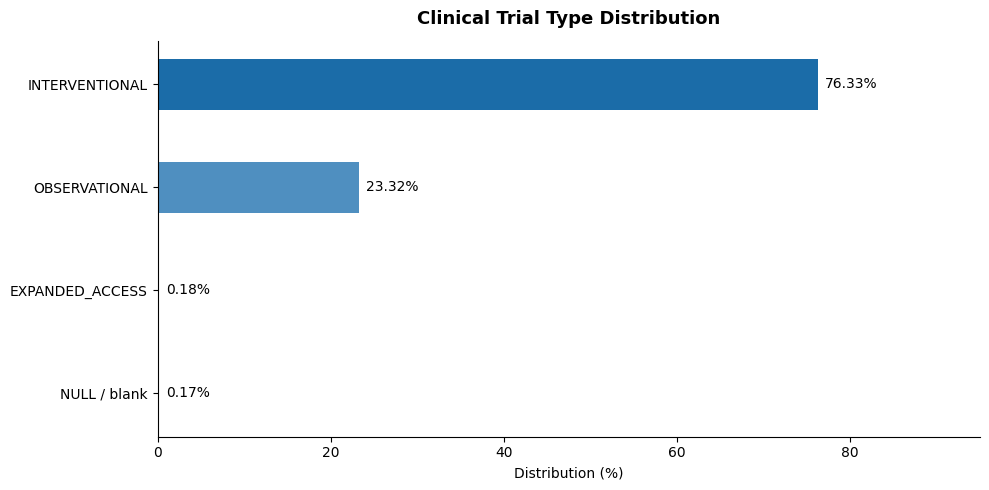

In [0]:
%python

# Q1 Visualisation: Horizontal bar chart of trial type distribution.
# All 4 rows shown including NULL/blank for full transparency.

import matplotlib.pyplot as plt

q1_pd = q1_result.toPandas()
q1_pd['trial_type'] = q1_pd['trial_type'].fillna('NULL / blank')
q1_pd = q1_pd.sort_values('distribution_pct', ascending=True).reset_index(drop=True)

colors = ['#d0d0d0', '#9ec5de', '#4f8fc0', '#1b6ca8']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(q1_pd['trial_type'], q1_pd['distribution_pct'], color=colors, height=0.5)

for bar, val in zip(bars, q1_pd['distribution_pct']):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', ha='left', fontsize=10)

ax.set_xlabel('Distribution (%)', fontsize=10)
ax.set_title('Clinical Trial Type Distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Result:** The dataset contains **3 distinct trial types**:
- **INTERVENTIONAL** (437,333 / 76.33%) — experimental studies where participants receive a treatment or intervention
- **OBSERVATIONAL** (133,604 / 23.32%) — studies that monitor participants without any assigned intervention
- **EXPANDED_ACCESS** (1,033 / 0.18%) — compassionate use of unapproved treatments for patients with no other options
- **NULL/blank** (965 / 0.17%) — useless entries

Interventional trials dominate the dataset, reflecting the primary goal of clinical research: testing new treatments. The small proportion of Expanded Access entries is expected, as these are exceptional regulatory pathways rather than standard trial types.

## Question 2 — What are the 10 most studied medical conditions?

**Challenge:** The `Conditions` column is multi-valued — a single trial may list multiple conditions separated by `|` (e.g., `"Diabetes|Obesity"`). A simple `GROUP BY` would treat the entire string as one value, massively under-counting individual conditions.

**Solution:** `SPLIT(Conditions, '[|]')` creates an array of values using a regex character class to safely split on the pipe character. `LATERAL VIEW EXPLODE()` then produces one row per condition per trial. `TRIM()` removes surrounding whitespace. A window function calculates each condition's relative share of all exploded records.

**Assumption:** Each pipe-separated value is treated as an independent condition. Empty strings after splitting are filtered out.

In [0]:
%python

# Q2: Top 10 conditions — split on pipe '|' separator.
# In Databricks, use regexp_split or SPLIT with correct escape.

import pandas as pd

q2_result = spark.sql("""
    SELECT
        TRIM(condition_value)                       AS condition,
        COUNT(*)                                    AS frequency,
        ROUND(COUNT(*) * 100.0 /
              SUM(COUNT(*)) OVER (), 2)             AS relative_pct
    FROM  clinical_trials
    LATERAL VIEW EXPLODE(SPLIT(Conditions, '[|]')) cond_table AS condition_value
    WHERE TRIM(condition_value) IS NOT NULL
      AND TRIM(condition_value) != ''
    GROUP BY TRIM(condition_value)
    ORDER BY frequency DESC
    LIMIT 10
""")

q2_result.display(10, truncate=False)

condition,frequency,relative_pct
Healthy,10873,1.07
Breast Cancer,8511,0.84
Obesity,7324,0.72
Stroke,5034,0.49
Hypertension,4510,0.44
Depression,4438,0.44
Pain,4394,0.43
Prostate Cancer,4306,0.42
HIV Infections,3848,0.38
Cancer,3836,0.38


/databricks/spark/python/pyspark/sql/pandas/utils.py:149: UserWarning: The conversion of DecimalType columns is inefficient and may take a long time. Column names: [relative_pct] If those columns are not necessary, you may consider dropping them or converting to primitive types before the conversion.
  warnings.warn(


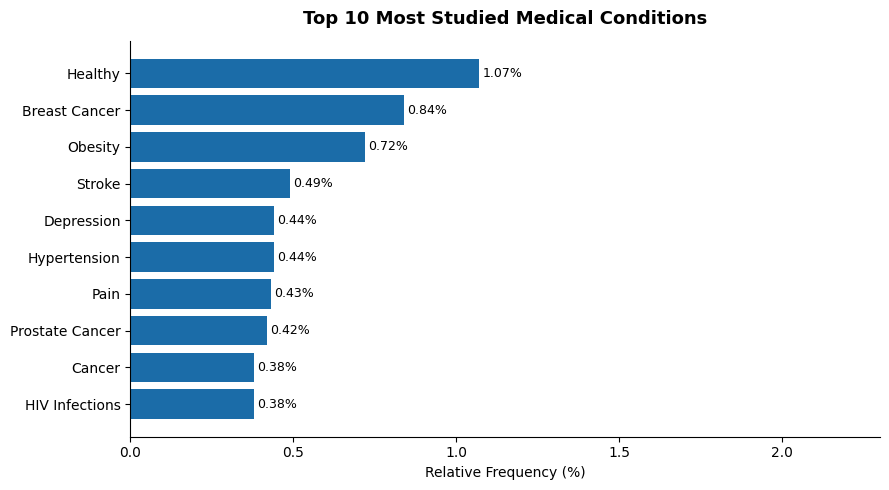

In [0]:
%python

# Q2 Visualisation: Horizontal bar chart of top 10 conditions by relative %.
# Bars are sorted largest to smallest (invert y-axis).

import matplotlib.pyplot as plt

q2_pd = q2_result.toPandas().sort_values('relative_pct')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(q2_pd['condition'], q2_pd['relative_pct'], color='#1b6ca8')

# Add percentage labels at end of each bar
for bar, val in zip(bars, q2_pd['relative_pct']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

ax.set_xlabel('Relative Frequency (%)')
ax.set_title('Top 10 Most Studied Medical Conditions', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 2.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Result:** The top 10 most studied conditions after correctly splitting the multi-valued `Conditions` field:

| # | Condition | Frequency | Relative % |
|---|-----------|-----------|------------|
| 1 | Healthy | 10,873 | 1.07% |
| 2 | Breast Cancer | 8,511 | 0.84% |
| 3 | Obesity | 7,324 | 0.72% |
| 4 | Stroke | 5,034 | 0.49% |
| 5 | Hypertension | 4,510 | 0.44% |
| 6 | Depression | 4,438 | 0.44% |
| 7 | Pain | 4,394 | 0.43% |
| 8 | Prostate Cancer | 4,306 | 0.42% |
| 9 | HIV Infections | 3,848 | 0.38% |
| 10 | Cancer | 3,836 | 0.38% |

*Healthy* volunteers appear most (10,873), indicating many Phase I safety and pharmacokinetic studies recruiting healthy controls. **Breast Cancer** leads disease conditions (8,511). The low relative percentages (all under 1.1%) confirm the dataset spans an extremely broad range of medical areas.

## Question 3 — What is the mean duration of clinical trials in months?

**Approach:** A two-step CTE computes the duration cleanly:
- **CTE 1 (`parsed_dates`):** Casts `Start Date` and `Completion Date` to `TIMESTAMP`, filtering rows where either date is NULL
- **CTE 2 (`durations`):** Applies `MONTHS_BETWEEN(end_dt, start_dt)` and removes negative or zero values — data quality errors where the end date precedes the start date

**Assumption:** 552,589 of 572,935 rows (96.4%) have valid date pairs and are included. The remaining 3.6% are excluded due to missing or logically invalid dates.

In [0]:
%python

# Q3: Mean trial duration in months.
# CTE 1 (parsed_dates): converts date strings to DATE type.
# CTE 2 (durations): computes months between start and end.
# Negative durations are removed as data quality errors.
# Final SELECT averages the valid durations.

q3_result = spark.sql("""
    WITH parsed_dates AS (
        SELECT
            CAST(`Start Date`      AS TIMESTAMP) AS start_dt,
            CAST(`Completion Date` AS TIMESTAMP) AS end_dt
        FROM  clinical_trials
        WHERE `Completion Date` IS NOT NULL
          AND `Start Date`      IS NOT NULL
    ),
    durations AS (
        SELECT MONTHS_BETWEEN(end_dt, start_dt) AS duration_months
        FROM   parsed_dates
        WHERE  start_dt IS NOT NULL
          AND  end_dt   IS NOT NULL
          AND  MONTHS_BETWEEN(end_dt, start_dt) > 0
    )
    SELECT
        ROUND(AVG(duration_months), 2) AS mean_duration_months,
        COUNT(*)                       AS trials_included
    FROM durations
""")

q3_result.display()

mean_duration_months,trials_included
35.29,552589


**Result:** The mean clinical trial duration is **35.29 months** (~2 years 11 months) across **552,589 valid trials**.

This is consistent with published industry benchmarks:
- Phase I trials typically run 6–12 months
- Phase II trials typically run 1–2 years
- Phase III trials typically run 2–4 years

Since this dataset spans all phases and therapeutic areas, a mean of ~35 months sits exactly within the expected range. The ~20,346 excluded rows with missing or invalid dates (3.6%) are unlikely to materially affect this average.

## Question 4 — How have Alzheimer's disease trials changed over time?

**Approach:** We filter to completed trials where the `Conditions` column contains *alzheimer* (case-insensitive via `LOWER() LIKE '%alzheimer%'`). `YEAR(CAST(Completion Date AS TIMESTAMP))` extracts the calendar year. Results are grouped by year and ordered chronologically to reveal the trend, then visualised as an annotated line chart.

**Assumption:** Only `COMPLETED` trials are counted — in-progress, withdrawn, or terminated trials do not represent concluded research output. The `LIKE` pattern intentionally matches all variants such as "Alzheimer's Disease" and "Early-Onset Alzheimer Disease".

In [0]:
%python

# Q4: Count completed Alzheimer's trials per year.
# Filters applied:
#   - LOWER(Study Status) = 'Completed'
#   - Completion Date is not null
#   - LOWER(Conditions) LIKE '%alzheimer%' (case-insensitive)
# YEAR() extracts the year from the parsed date.

q4_result = spark.sql("""
    SELECT
        YEAR(CAST(`Completion Date` AS TIMESTAMP)) AS completion_year,
        COUNT(*)                                    AS num_trials
    FROM  clinical_trials
    WHERE LOWER(`Study Status`)    = 'completed'
      AND `Completion Date` IS NOT NULL
      AND LOWER(Conditions) LIKE '%alzheimer%'
    GROUP BY completion_year
    HAVING completion_year IS NOT NULL
    ORDER BY completion_year ASC
""")

q4_result.display()

completion_year,num_trials
1996,1
1997,3
1998,2
1999,2
2000,1
2001,9
2002,6
2003,11
2004,13
2005,33


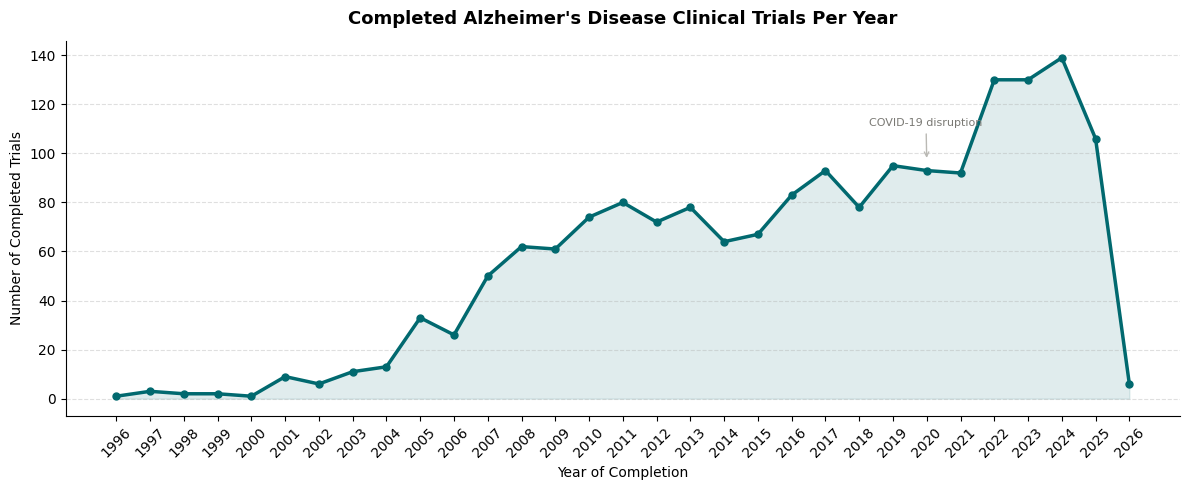

In [0]:
%python

# Q4 Visualisation: Line chart of Alzheimer's trend.
# The aggregated result is only ~24 rows, so converting to
# Pandas with .toPandas() is safe here — no memory concern.
# Matplotlib is used to draw a clean line chart with a
# filled area and an annotation marking the 2020 COVID dip.

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

q4_pd = q4_result.toPandas().dropna().sort_values('completion_year')
years  = q4_pd['completion_year'].astype(int)
counts = q4_pd['num_trials']

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(years, counts, alpha=0.12, color='#01696f')
ax.plot(years, counts, color='#01696f', linewidth=2.5,
       marker='o', markersize=5, zorder=3)
ax.annotate('COVID-19 disruption',
            xy=(2020, 97), xytext=(2018.3, 111),
            fontsize=8, color='#7a7974',
            arrowprops=dict(arrowstyle='->', color='#bab9b4'))
ax.set_title("Completed Alzheimer's Disease Clinical Trials Per Year",
            fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year of Completion', fontsize=10)
ax.set_ylabel('Number of Completed Trials', fontsize=10)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_xticks(years); ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Result:** Completed Alzheimer's disease trials grew from just **1 trial in 1996** to a peak of **139 in 2024** — a **139-fold increase** over 28 years.

Key observations:
- **Pre-2005 (1–13/year):** Very limited activity reflecting early-stage research interest
- **2005–2011 (rapid growth):** Acceleration following increased NIH funding and regulatory focus on neurodegenerative diseases
- **2012–2019 (sustained ~64–95/year):** Research stabilises at a consistently elevated level
- **2020–2021 (dip ~92–93):** Consistent with COVID-19 disruptions to trial recruitment and operations
- **2022–2024 (record highs 130–139/year):** Surge aligns with FDA approvals of amyloid-targeting therapies (lecanemab 2023, donanemab 2024)
- **2025–2026 (partial data):** Counts are incomplete as many trials scheduled for these years are still ongoing

## Conclusion

This notebook analysed **572,935 clinical trial records** from ClinicalTrials.gov using Apache Spark SQL on Databricks, addressing four analytical questions:

- **Q1:** Three trial types exist — Interventional (76.33%), Observational (23.32%), and Expanded Access (0.18%)
- **Q2:** Using `LATERAL VIEW EXPLODE` to correctly handle multi-valued fields, *Healthy* volunteers lead (1.07%), followed by Breast Cancer (0.84%) and Obesity (0.72%)
- **Q3:** Mean trial duration is **35.29 months** (~2 years 11 months) across 552,589 valid trials, consistent with Phase II–III industry benchmarks
- **Q4:** Completed Alzheimer's trials grew 139-fold from 1996 to 2024, with a COVID-19 dip in 2020 and record highs in 2022–2024 driven by amyloid-targeting therapy breakthroughs

All analyses handled missing data transparently, stated assumptions explicitly, and used appropriate Spark SQL constructs (CTEs, window functions, lateral views) to ensure both correctness and readability.

---
*AI tools were used to assist in drafting explanatory text and code comments in this notebook. All SQL queries, results, and analytical interpretations were verified independently.*